# Step 2: Model Training and Optimizer Comparison
Using ResNet50 as the backbone, and a Generalized Intersection over Union (GIoU) loss. MSE is poor for bounding boxes. GIoU leads to much more exact locations. We'll also compare optimizers as required.

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Model
import cv2
import os
import matplotlib.pyplot as plt

# Configuration
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10
DATA_DIR = '../data/training_images'
CSV_PATH = '../data/cleaned_bounding_boxes.csv'

df = pd.read_csv(CSV_PATH)

### 1. Custom GIoU Loss
MSE treats coordinates independently. GIoU is geometric and maximizes overlap.

In [2]:
def giou_loss(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)
    
    p_xmin, p_ymin, p_xmax, p_ymax = y_pred[:, 0], y_pred[:, 1], y_pred[:, 2], y_pred[:, 3]
    g_xmin, g_ymin, g_xmax, g_ymax = y_true[:, 0], y_true[:, 1], y_true[:, 2], y_true[:, 3]
    
    p_area = tf.maximum(p_xmax - p_xmin, 0.0) * tf.maximum(p_ymax - p_ymin, 0.0)
    g_area = tf.maximum(g_xmax - g_xmin, 0.0) * tf.maximum(g_ymax - g_ymin, 0.0)
    
    inter_xmin = tf.maximum(p_xmin, g_xmin)
    inter_ymin = tf.maximum(p_ymin, g_ymin)
    inter_xmax = tf.minimum(p_xmax, g_xmax)
    inter_ymax = tf.minimum(p_ymax, g_ymax)
    inter_area = tf.maximum(inter_xmax - inter_xmin, 0.0) * tf.maximum(inter_ymax - inter_ymin, 0.0)
    
    union_area = p_area + g_area - inter_area + 1e-7
    iou = inter_area / union_area
    
    enc_xmin = tf.minimum(p_xmin, g_xmin)
    enc_ymin = tf.minimum(p_ymin, g_ymin)
    enc_xmax = tf.maximum(p_xmax, g_xmax)
    enc_ymax = tf.maximum(p_ymax, g_ymax)
    enc_area = tf.maximum(enc_xmax - enc_xmin, 0.0) * tf.maximum(enc_ymax - enc_ymin, 0.0) + 1e-7
    
    giou = iou - (enc_area - union_area) / enc_area
    return tf.reduce_mean(1.0 - giou)

### 2. Data Generator
Loads images, normalizes bounding boxes to [0,1], and applies standard ResNet preprocessing.

In [3]:
class CarDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, img_dir, batch_size=16):
        self.df = df
        self.img_dir = img_dir
        self.batch_size = batch_size
        self.indices = np.arange(len(self.df))
        np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

    def __getitem__(self, index):
        batch_indices = self.indices[index*self.batch_size:(index+1)*self.batch_size]
        batch_df = self.df.iloc[batch_indices]
        
        images, boxes = [], []
        for _, row in batch_df.iterrows():
            img_path = os.path.join(self.img_dir, row['image'])
            img = cv2.imread(img_path)
            if img is None: continue
            
            h, w = img.shape[:2]
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32)
            img = tf.keras.applications.resnet50.preprocess_input(img)
            
            # Normalize bounding box
            box = [row['xmin']/w, row['ymin']/h, row['xmax']/w, row['ymax']/h]
            box = np.clip(box, 0.0, 1.0)
            
            images.append(img)
            boxes.append(box)
            
        return np.array(images), np.array(boxes)

# Train/Val Split
split_idx = int(len(df) * 0.8)
train_gen = CarDataGenerator(df.iloc[:split_idx], DATA_DIR, BATCH_SIZE)
val_gen = CarDataGenerator(df.iloc[split_idx:], DATA_DIR, BATCH_SIZE)

### 3. Model Building & Optimizer Comparison
We test `Adam`, `SGD`, `RMSprop`, and `Adagrad`.

In [4]:
def build_model():
    backbone = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    backbone.trainable = False # Freeze backbone
    
    x = backbone.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(4, activation='sigmoid', name='bbox')(x) # Sigmoid limits output to [0, 1]
    
    return Model(inputs=backbone.input, outputs=outputs)

optimizers = {
    'Adam': tf.keras.optimizers.Adam(learning_rate=1e-4),
    'SGD': tf.keras.optimizers.SGD(learning_rate=1e-3, momentum=0.9),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=1e-4),
    'Adagrad': tf.keras.optimizers.Adagrad(learning_rate=1e-2)
}

histories = {}
os.makedirs('../models', exist_ok=True)

for name, opt in optimizers.items():
    print(f"\n--- Training with {name} ---")
    model = build_model()
    model.compile(optimizer=opt, loss=giou_loss, metrics=['mae'])
    
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        verbose=1
    )
    histories[name] = history.history
    model.save(f'../models/resnet50_{name}.keras')


--- Training with Adam ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 30s 0us/step


c:\Users\Nistha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - loss: 1.5462 - mae: 0.2390

c:\Users\Nistha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


17/17 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - loss: 1.4700 - mae: 0.2380 - val_loss: 1.6211 - val_mae: 0.2701
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 821ms/step - loss: 1.2019 - mae: 0.3209 - val_loss: 1.2049 - val_mae: 0.3887
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 781ms/step - loss: 1.0223 - mae: 0.4671 - val_loss: 1.0387 - val_mae: 0.4731
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 793ms/step - loss: 1.0033 - mae: 0.5175 - val_loss: 1.0015 - val_mae: 0.4956
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 792ms/step - loss: 1.0000 - mae: 0.5312 - val_loss: 1.0000 - val_mae: 0.5006
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 797ms/step - loss: 1.0000 - mae: 0.5319 - val_loss: 1.0000 - val_mae: 0.5008
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 796ms/step - loss: 1.0000 - mae: 0.5342 - val_loss: 1.0000 - val_mae: 0.5032
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 798ms/step - loss: 1.0000 - mae: 0.5341 - val_loss: 1.0000 - val_mae: 0.5033
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 810ms/step - loss: 1

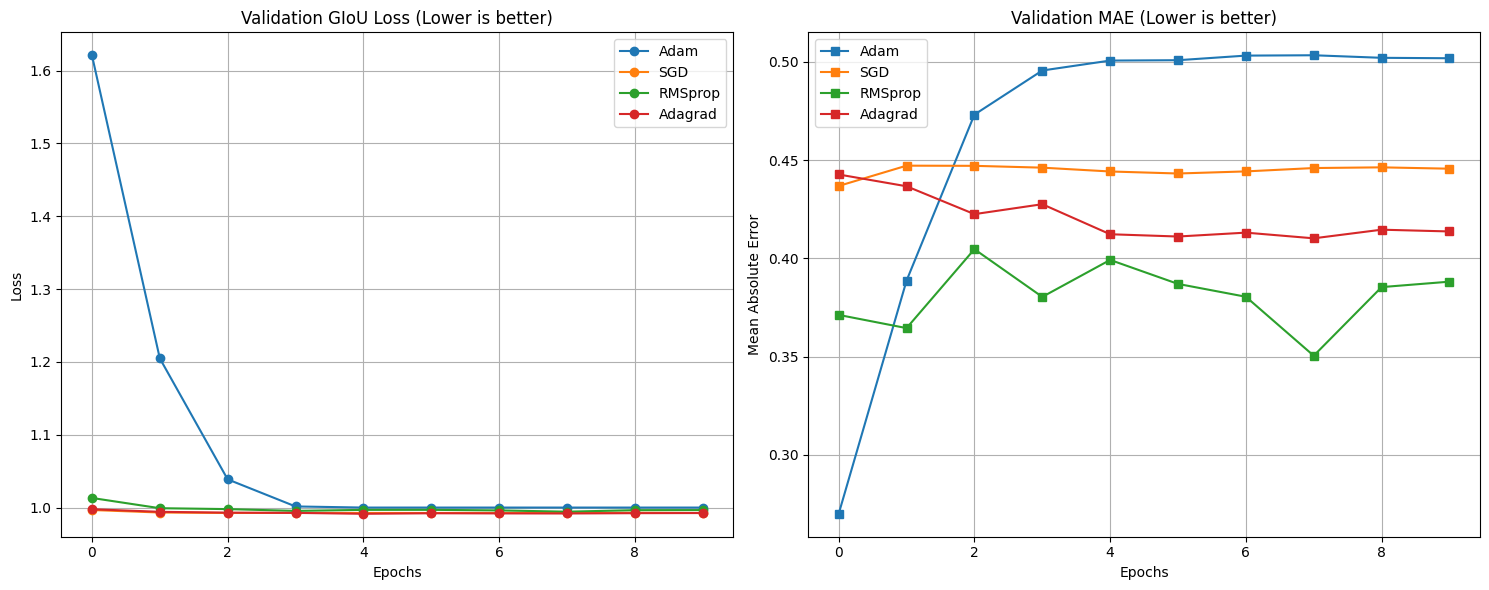

In [5]:
# Plotting Comparison
plt.figure(figsize=(15, 6))

# Validation Loss (GIoU)
plt.subplot(1, 2, 1)
for name, hist in histories.items():
    plt.plot(hist['val_loss'], label=name, marker='o')
plt.title('Validation GIoU Loss (Lower is better)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Validation MAE
plt.subplot(1, 2, 2)
for name, hist in histories.items():
    plt.plot(hist['val_mae'], label=name, marker='s')
plt.title('Validation MAE (Lower is better)')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)

plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/optimizer_comparison.png')
plt.show()